# 04 — Modelo LSTM para Análisis de Sentimiento (IMDB)

Este notebook entrena una red neuronal recurrente **LSTM** sobre el dataset IMDB.Los datos ya fueron preprocesados en `02_preprocessing.ipynb` y se cargan directamente desde `../data/processed/`.

### Estructura del notebook
1. Imports y configuración  
2. Carga de datos preprocesados  
3. Definición de la arquitectura LSTM  
4. Entrenamiento con Early Stopping  
5. Curvas de entrenamiento  
6. Evaluación en test set  
7. Análisis de errores  
8. Guardado del modelo  


## Celda 1 — Instalación de dependencias

In [1]:
!pip install tensorflow scikit-learn matplotlib seaborn numpy pandas joblib

## Celda 2 — Imports y configuración

Se fija la semilla aleatoria para reproducibilidad.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (
    Embedding, Bidirectional, LSTM, Dense, Dropout, SpatialDropout1D
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, roc_auc_score
)

# Reproducibilidad
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

os.makedirs('../models', exist_ok=True)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU disponible: {len(tf.config.list_physical_devices('GPU')) > 0}")


I0000 00:00:1779345013.069341    3803 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.21.0
GPU disponible: False


W0000 00:00:1779345017.207461    3803 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


## Celda 3 — Carga de datos preprocesados

Se cargan las secuencias padded y los labels generados en `02_preprocessing.ipynb`.  
- Vocabulario: **20 000 tokens**  
- Longitud de secuencia: **400 tokens** (percentil 95 del EDA)

In [3]:
# Hiperparámetros de preprocesamiento (deben coincidir con 02_preprocessing.ipynb)
MAX_WORDS = 20_000   # tamaño del vocabulario
MAX_LEN   = 400      # longitud de secuencia padded

# Cargar secuencias
X_train = np.load('../data/processed/seq_train_imdb.npy')
X_val   = np.load('../data/processed/seq_val_imdb.npy')
X_test  = np.load('../data/processed/seq_test_imdb.npy')

# Cargar labels
y_train = np.load('../data/processed/y_train_imdb.npy')
y_val   = np.load('../data/processed/y_val_imdb.npy')
y_test  = np.load('../data/processed/y_test_imdb.npy')

# Cargar tokenizador (para análisis de errores)
tok = joblib.load('../data/processed/tokenizer_imdb.pkl')

print("Shapes cargados:")
print(f"  X_train : {X_train.shape}   y_train : {y_train.shape}")
print(f"  X_val   : {X_val.shape}     y_val   : {y_val.shape}")
print(f"  X_test  : {X_test.shape}    y_test  : {y_test.shape}")
print()
print("Distribución de clases:")
for split_name, y_split in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    pos = y_split.mean() * 100
    print(f"  {split_name:5s} — positivos: {pos:.1f}%  negativos: {100 - pos:.1f}%")


Shapes cargados:
  X_train : (35020, 400)   y_train : (35020,)
  X_val   : (7480, 400)     y_val   : (7480,)
  X_test  : (7500, 400)    y_test  : (7500,)

Distribución de clases:
  Train — positivos: 50.0%  negativos: 50.0%
  Val   — positivos: 50.0%  negativos: 50.0%
  Test  — positivos: 50.0%  negativos: 50.0%


## Celda 4 — Definición de la arquitectura LSTM

### Decisiones de diseño

| Componente | Elección | Justificación |
|---|---|---|
| Embedding | 128 dims, trainable | Aprende representaciones específicas del dominio |
| SpatialDropout1D | 0.3 | Regularización a nivel de embedding, más efectiva que Dropout estándar en secuencias |
| LSTM | 128 unidades | Captura contexto tanto hacia adelante como hacia atrás |
| Dropout | 0.3 | Regularización entre capas recurrentes |
| LSTM | 64 unidades | Segunda capa recurrente, menor dimensión para forzar abstracción |
| Dense | 64 → sigmoid | Clasificador binario final |

> Se usa **LSTM** porque en análisis de sentimiento el contexto completo (palabras previas y posteriores) aporta información relevante para la clasificación.

In [4]:
# ── Hiperparámetros del modelo ──────────────────────────────────────────────
EMBEDDING_DIM = 64
LSTM_UNITS    = 128
DENSE_UNITS   = 32
DROPOUT_RATE  = 0.3
SPATIAL_DROP  = 0.3

def construir_modelo(max_words, max_len, emb_dim, lstm_units, dense, dropout):
    model = Sequential([
        # Capa de embeddings: convierte cada token entero en un vector denso
        Embedding(
            input_dim=max_words,
            output_dim=emb_dim,
            input_length=max_len,
            name='embedding'
        ),

        # SpatialDropout1D apaga filas completas del embedding (más efectivo en NLP)
        SpatialDropout1D(SPATIAL_DROP, name='spatial_dropout'),

        # LSTM unidireccional — procesa la secuencia de izquierda a derecha
        # Sin recurrent_dropout para mantener la aceleración cuDNN activa
        LSTM(lstm_units, return_sequences=False, name='lstm_1'),
        Dropout(dropout, name='dropout_1'),

        # Clasificador
        Dense(dense, activation='relu', name='dense_1'),
        Dropout(dropout / 2, name='dropout_2'),

        # Salida binaria
        Dense(1, activation='sigmoid', name='output')
    ], name='LSTM_Sentiment')
    return model

model = construir_modelo(
    MAX_WORDS, MAX_LEN, EMBEDDING_DIM,
    LSTM_UNITS, DENSE_UNITS, DROPOUT_RATE
)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "LSTM_Sentiment"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout                 │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Celda 5 — Entrenamiento

### Estrategia de entrenamiento

| Parámetro | Valor | Justificación |
|---|---|---|
| Loss | Binary Cross-Entropy | Tarea de clasificación binaria |
| Optimizer | Adam lr=1e-3 | Convergencia rápida y estable |
| Batch size | 64 | Balance entre velocidad y estabilidad del gradiente |
| Epochs máx | 15 | Suficiente para converger con Early Stopping |
| Early Stopping | patience=3, val_loss | Evita overfitting, restaura los mejores pesos |
| ReduceLROnPlateau | factor=0.5, patience=2 | Reduce lr cuando el val_loss se estanca |
| ModelCheckpoint | mejor val_loss | Guarda el mejor modelo automáticamente |

In [5]:
# ── Truncar secuencias a 200 tokens ─────────────────────────────────────────
# La mediana IMDB tras limpiar stopwords queda muy por debajo de 400.
# 200 tokens captura la mayoría de reseñas con la mitad del cómputo.
MAX_LEN = 200
X_train_t = X_train[:, :MAX_LEN]
X_val_t   = X_val[:,   :MAX_LEN]
X_test_t  = X_test[:,  :MAX_LEN]
print(f"Secuencias truncadas a {MAX_LEN} tokens.")

# ── Hiperparámetros de entrenamiento ────────────────────────────────────────
BATCH_SIZE = 128   # aumentado de 64: menos pasos por época
EPOCHS     = 10
CKPT_PATH  = '../models/lstm_best.keras'

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    filepath=CKPT_PATH,
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

print("Iniciando entrenamiento...")
print(f"  Train:  {X_train_t.shape[0]:,} muestras  |  seq_len: {MAX_LEN}")
print(f"  Val:    {X_val_t.shape[0]:,} muestras")
print(f"  Batch:  {BATCH_SIZE}  |  Epochs máx: {EPOCHS}")
print()

history = model.fit(
    X_train_t, y_train,
    validation_data=(X_val_t, y_val),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=[early_stop, checkpoint, reduce_lr],
    verbose=1
)

print()
print(f"Entrenamiento completado en {len(history.history['loss'])} épocas.")


Secuencias truncadas a 200 tokens.
Iniciando entrenamiento...
  Train:  35,020 muestras  |  seq_len: 200
  Val:    7,480 muestras
  Batch:  128  |  Epochs máx: 10

Epoch 1/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step - accuracy: 0.5036 - loss: 0.6933
Epoch 1: val_loss improved from None to 0.69015, saving model to ../models/lstm_best.keras

Epoch 1: finished saving model to ../models/lstm_best.keras
274/274 ━━━━━━━━━━━━━━━━━━━━ 84s 298ms/step - accuracy: 0.5073 - loss: 0.6927 - val_accuracy: 0.5111 - val_loss: 0.6901 - learning_rate: 0.0010
Epoch 2/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - accuracy: 0.5288 - loss: 0.6827
Epoch 2: val_loss improved from 0.69015 to 0.68834, saving model to ../models/lstm_best.keras

Epoch 2: finished saving model to ../models/lstm_best.keras
274/274 ━━━━━━━━━━━━━━━━━━━━ 79s 290ms/step - accuracy: 0.5401 - loss: 0.6745 - val_accuracy: 0.5112 - val_loss: 0.6883 - learning_rate: 0.0010
Epoch 3/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step - accuracy:

## Celda 6 — Curvas de entrenamiento

Se grafican la pérdida y la exactitud en train y validación para analizar overfitting/underfitting.

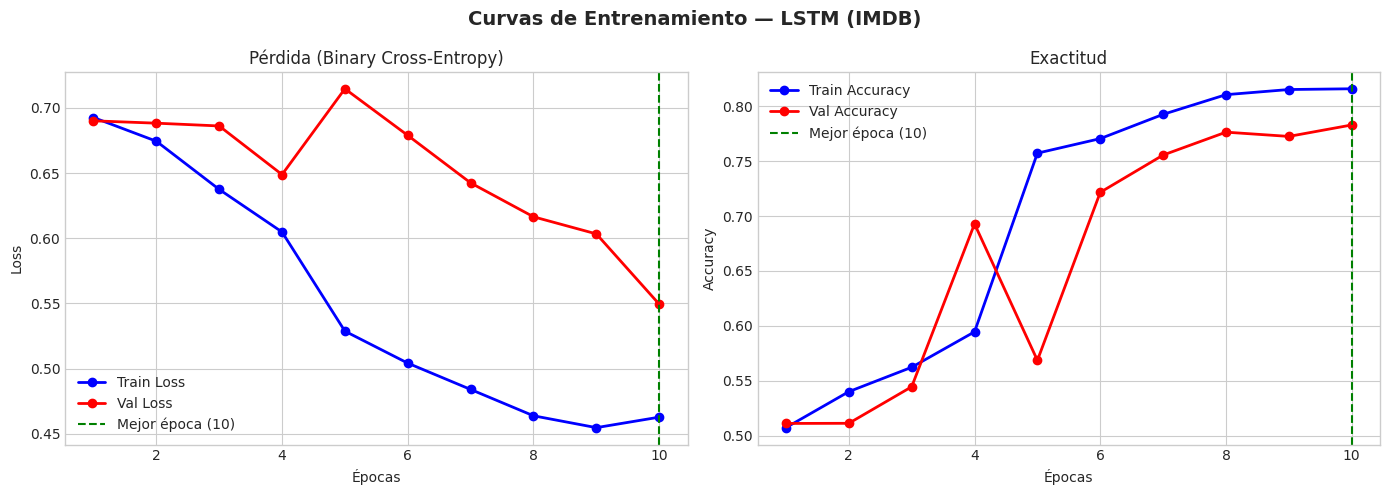

Mejor época:        10
Mejor val_loss:     0.5494
Val accuracy:       0.7830  (78.30%)

Diagnóstico: buena generalización (gap train-val = 0.033)


In [6]:
epochs_ran = range(1, len(history.history['loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Curvas de Entrenamiento — LSTM (IMDB)', fontsize=14, fontweight='bold')

# ── Pérdida ──────────────────────────────────────────────────────────────────
axes[0].plot(epochs_ran, history.history['loss'],     'b-o', label='Train Loss',   linewidth=2)
axes[0].plot(epochs_ran, history.history['val_loss'], 'r-o', label='Val Loss',     linewidth=2)
best_epoch = np.argmin(history.history['val_loss']) + 1
axes[0].axvline(best_epoch, color='green', linestyle='--', linewidth=1.5, label=f'Mejor época ({best_epoch})')
axes[0].set_title('Pérdida (Binary Cross-Entropy)')
axes[0].set_xlabel('Épocas')
axes[0].set_ylabel('Loss')
axes[0].legend()

# ── Exactitud ─────────────────────────────────────────────────────────────────
axes[1].plot(epochs_ran, history.history['accuracy'],     'b-o', label='Train Accuracy', linewidth=2)
axes[1].plot(epochs_ran, history.history['val_accuracy'], 'r-o', label='Val Accuracy',   linewidth=2)
axes[1].axvline(best_epoch, color='green', linestyle='--', linewidth=1.5, label=f'Mejor época ({best_epoch})')
axes[1].set_title('Exactitud')
axes[1].set_xlabel('Épocas')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig('../models/lstm_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Resumen numérico ─────────────────────────────────────────────────────────
best_val_loss = min(history.history['val_loss'])
best_val_acc  = history.history['val_accuracy'][np.argmin(history.history['val_loss'])]
print(f"Mejor época:        {best_epoch}")
print(f"Mejor val_loss:     {best_val_loss:.4f}")
print(f"Val accuracy:       {best_val_acc:.4f}  ({best_val_acc*100:.2f}%)")

# Diagnóstico de overfitting
gap = history.history['accuracy'][-1] - history.history['val_accuracy'][-1]
if gap > 0.05:
    print(f"\nDiagnóstico: posible OVERFITTING (gap train-val = {gap:.3f})")
elif gap < -0.02:
    print(f"\nDiagnóstico: posible UNDERFITTING (gap train-val = {gap:.3f})")
else:
    print(f"\nDiagnóstico: buena generalización (gap train-val = {gap:.3f})")


## Celda 7 — Evaluación en el conjunto de test

Se usa el modelo con los mejores pesos (`ModelCheckpoint`) para evaluar en el conjunto de test.

In [7]:
best_model = load_model(CKPT_PATH)

y_prob_test = best_model.predict(X_test_t, batch_size=256, verbose=0).flatten()
y_pred_test = (y_prob_test >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred_test)
f1  = f1_score(y_test, y_pred_test)
auc = roc_auc_score(y_test, y_prob_test)

print("=" * 55)
print("       EVALUACIÓN EN TEST SET — LSTM (IMDB)")
print("=" * 55)
print(f"  Accuracy :  {acc:.4f}   ({acc*100:.2f}%)")
print(f"  F1-Score :  {f1:.4f}")
print(f"  ROC-AUC  :  {auc:.4f}")
print()
print(classification_report(y_test, y_pred_test, target_names=['Negativo', 'Positivo']))

y_pred_train = (best_model.predict(X_train_t, batch_size=256, verbose=0).flatten() >= 0.5).astype(int)
y_pred_val   = (best_model.predict(X_val_t,   batch_size=256, verbose=0).flatten() >= 0.5).astype(int)

acc_train = accuracy_score(y_train, y_pred_train)
acc_val   = accuracy_score(y_val,   y_pred_val)

print()
print("Comparación train / val / test:")
print(f"  Train accuracy : {acc_train:.4f}")
print(f"  Val   accuracy : {acc_val:.4f}")
print(f"  Test  accuracy : {acc:.4f}")


       EVALUACIÓN EN TEST SET — LSTM (IMDB)
  Accuracy :  0.7845   (78.45%)
  F1-Score :  0.7949
  ROC-AUC  :  0.7940

              precision    recall  f1-score   support

    Negativo       0.82      0.73      0.77      3750
    Positivo       0.76      0.84      0.79      3750

    accuracy                           0.78      7500
   macro avg       0.79      0.78      0.78      7500
weighted avg       0.79      0.78      0.78      7500


Comparación train / val / test:
  Train accuracy : 0.8267
  Val   accuracy : 0.7830
  Test  accuracy : 0.7845


## Celda 8 — Matriz de confusión

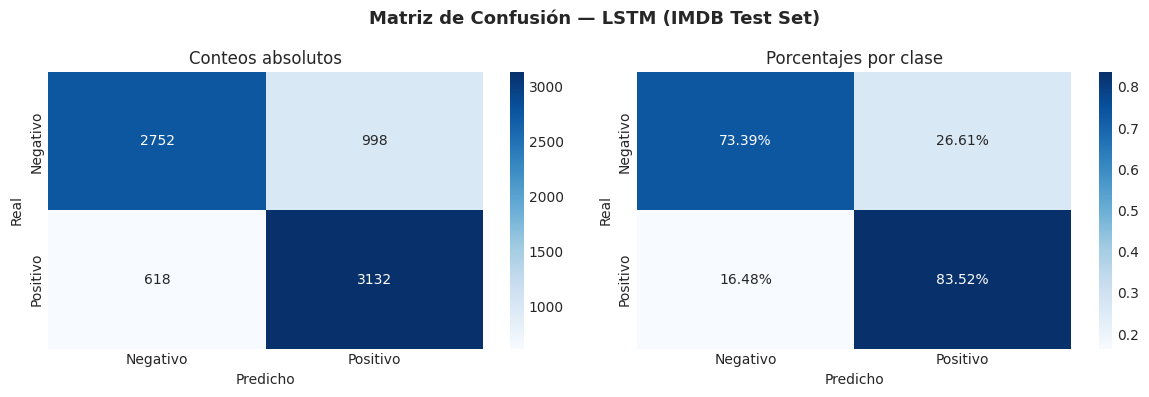

Verdaderos Negativos  (TN): 2,752
Falsos Positivos      (FP): 998  ← negativos clasificados como positivos
Falsos Negativos      (FN): 618  ← positivos clasificados como negativos
Verdaderos Positivos  (TP): 3,132


In [8]:
cm = confusion_matrix(y_test, y_pred_test)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Matriz de Confusión — LSTM (IMDB Test Set)', fontsize=13, fontweight='bold')

labels = ['Negativo', 'Positivo']

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=labels, yticklabels=labels)
axes[0].set_title('Conteos absolutos')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predicho')

sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
            xticklabels=labels, yticklabels=labels)
axes[1].set_title('Porcentajes por clase')
axes[1].set_ylabel('Real')
axes[1].set_xlabel('Predicho')

plt.tight_layout()
plt.savefig('../models/lstm_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"Verdaderos Negativos  (TN): {tn:,}")
print(f"Falsos Positivos      (FP): {fp:,}  ← negativos clasificados como positivos")
print(f"Falsos Negativos      (FN): {fn:,}  ← positivos clasificados como negativos")
print(f"Verdaderos Positivos  (TP): {tp:,}")


## Celda 9 — Análisis de errores

Se identifican ejemplos donde el modelo falla con alta confianza para entender los límites del modelo.

ANÁLISIS DE ERRORES — Ejemplos con mayor confianza incorrecta

[Ejemplo 1] FN (pos→neg)
  Real: Positivo    |  Predicho: Negativo    |  P(pos)=0.000
  Texto: since starting read book movie based mixed feelings filmed result learned time ago see movie adaptation book read book found read book first inevitably disappointed film would undoubtedly true whereas case atonement probably best filmed adaptation book ever seen would probably mattered trying figure cause suspect point finger squarely michael cunningham much respect hours read saw awed cannot escape feeling much adapted susan <OOV> book take characters basic premise write movie dislike movie actually love movie since started reading novel...
----------------------------------------------------------------------

[Ejemplo 2] FP (neg→pos)
  Real: Negativo    |  Predicho: Positivo    |  P(pos)=0.999
  Texto: saucy misadventures four au pairs arrive london day early swedish girl danish german chinese story <OOV> get clothes involve ca

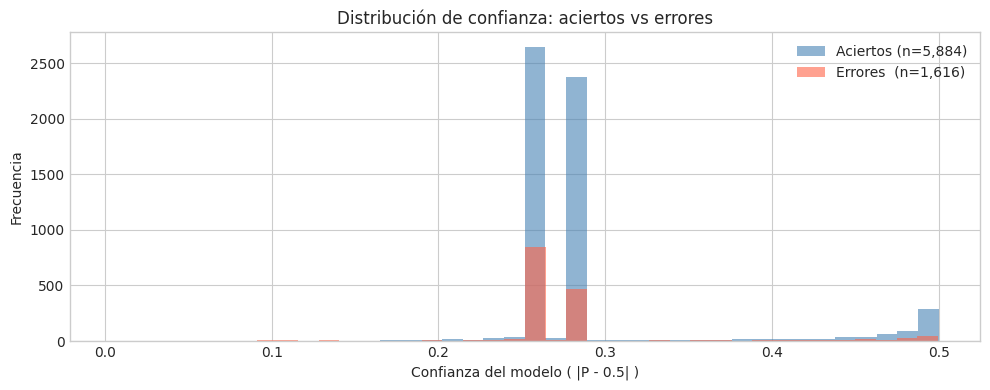


Confianza media en aciertos: 0.287
Confianza media en errores:  0.277


In [9]:
# Reconstruir índice inverso del tokenizador
idx_a_palabra = {v: k for k, v in tok.word_index.items()}

def secuencia_a_texto(seq):
    """Convierte una secuencia de enteros de vuelta a texto legible."""
    palabras = [idx_a_palabra.get(idx, '') for idx in seq if idx > 0]
    return ' '.join(palabras[:80])  # mostrar las primeras 80 palabras

# Recargar texto limpio para comparar con texto real
errores_mask = y_pred_test != y_test

# Índices de errores con alta confianza (el modelo estaba muy seguro pero se equivocó)
confianza_error = np.abs(y_prob_test[errores_mask] - 0.5)
idx_errores = np.where(errores_mask)[0]
top_errores = idx_errores[np.argsort(confianza_error)[::-1][:6]]

print("=" * 70)
print("ANÁLISIS DE ERRORES — Ejemplos con mayor confianza incorrecta")
print("=" * 70)

for i, idx in enumerate(top_errores):
    real      = int(y_test[idx])
    predicho  = int(y_pred_test[idx])
    prob      = y_prob_test[idx]
    texto     = secuencia_a_texto(X_test[idx])
    
    tipo = "FP (neg→pos)" if real == 0 else "FN (pos→neg)"
    print()
    print(f"[Ejemplo {i+1}] {tipo}")
    print(f"  Real: {'Positivo' if real == 1 else 'Negativo':10s}  |  Predicho: {'Positivo' if predicho == 1 else 'Negativo':10s}  |  P(pos)={prob:.3f}")
    print(f"  Texto: {texto}...")
    print("-" * 70)

# Distribución de confianza en errores vs aciertos
fig, ax = plt.subplots(figsize=(10, 4))
aciertos_prob = np.abs(y_prob_test[~errores_mask] - 0.5)
errores_prob  = np.abs(y_prob_test[ errores_mask] - 0.5)

ax.hist(aciertos_prob, bins=40, alpha=0.6, color='steelblue', label=f'Aciertos (n={len(aciertos_prob):,})')
ax.hist(errores_prob,  bins=40, alpha=0.6, color='tomato',    label=f'Errores  (n={len(errores_prob):,})')
ax.set_xlabel('Confianza del modelo ( |P - 0.5| )')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de confianza: aciertos vs errores')
ax.legend()
plt.tight_layout()
plt.savefig('../models/lstm_error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nConfianza media en aciertos: {aciertos_prob.mean():.3f}")
print(f"Confianza media en errores:  {errores_prob.mean():.3f}")


## Celda 10 — Guardado del modelo y resumen final

In [11]:
import json

resumen = {
    "modelo": "LSTM",
    "dataset": "IMDB 50K",
    "hiperparametros": {
        "max_words": int(MAX_WORDS),
        "max_len": int(MAX_LEN),
        "embedding_dim": int(EMBEDDING_DIM),
        "lstm_units": int(LSTM_UNITS),
        "dense_units": int(DENSE_UNITS),
        "dropout_rate": float(DROPOUT_RATE),
        "batch_size": int(BATCH_SIZE),
        "optimizer": "Adam",
        "learning_rate": 1e-3,
        "loss": "binary_crossentropy"
    },
    "entrenamiento": {
        "epochs_ran": int(len(history.history['loss'])),
        "best_epoch": int(best_epoch),
        "best_val_loss": round(float(best_val_loss), 4)
    },
    "metricas_test": {
        "accuracy": round(float(acc),  4),
        "f1_score": round(float(f1),   4),
        "roc_auc":  round(float(auc),  4)
    }
}

with open('../models/lstm_results.json', 'w') as f:
    json.dump(resumen, f, indent=2)

print("=" * 55)
print("            RESUMEN FINAL — LSTM")
print("=" * 55)
print(f"  Modelo guardado  : {CKPT_PATH}")
print(f"  Resultados JSON  : ../models/lstm_results.json")
print()
print("  Métricas en test:")
print(f"    Accuracy  : {acc:.4f}")
print(f"    F1-Score  : {f1:.4f}")
print(f"    ROC-AUC   : {auc:.4f}")
print()
print("  Comparación de splits:")
print(f"    Train: {acc_train:.4f}  Val: {acc_val:.4f}  Test: {acc:.4f}")

            RESUMEN FINAL — LSTM
  Modelo guardado  : ../models/lstm_best.keras
  Resultados JSON  : ../models/lstm_results.json

  Métricas en test:
    Accuracy  : 0.7845
    F1-Score  : 0.7949
    ROC-AUC   : 0.7940

  Comparación de splits:
    Train: 0.8267  Val: 0.7830  Test: 0.7845
